In [ ]:
#import necessary libraries
import numpy as np
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
#import dataset
dataset = pd.read_csv('/content/Churn_Modelling (2).csv')
dataset.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
X=dataset.iloc[:, 3:-1].values    #take 3 to one before last
y=dataset.iloc[:, -1].values
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [ ]:
print(y)

[1 0 1 ... 1 1 0]


In [ ]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
X[:, 2]=le.fit_transform(X[:,2])
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [ ]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier.fit(X_train, y_train)
pred=classifier.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score
cm = confusion_matrix(y_test, pred)
print(cm)


[[1379  216]
 [ 174  231]]


In [ ]:
print(accuracy_score(y_test, pred))

0.805


In [ ]:
#pip install keras

In [ ]:
import keras

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

In [ ]:
classifier = Sequential()

**Task 1**

In [ ]:
from keras.models import Sequential
from keras.layers import Dense

modelA = Sequential()

# Input + Hidden Layer
modelA.add(Dense(units=16, activation='relu', input_dim=12))

# Output Layer
modelA.add(Dense(units=1, activation='sigmoid'))

modelA.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyA = modelA.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=10,
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.7892 - loss: 0.4800 - val_accuracy: 0.8100 - val_loss: 0.4373
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.8241 - loss: 0.4171 - val_accuracy: 0.8206 - val_loss: 0.4194
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8358 - loss: 0.3985 - val_accuracy: 0.8269 - val_loss: 0.4023
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8461 - loss: 0.3813 - val_accuracy: 0.8331 - val_loss: 0.3861
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8514 - loss: 0.3678 - val_accuracy: 0.8400 - val_loss: 0.3761
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8566 - loss: 0.3586 - val_accuracy: 0.8425 - val_loss: 0.3711
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8564 - loss: 0.3531 - val_accuracy: 0.8400 - val_loss: 0.3678
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8589 - loss: 0.3496 - val_accu

In [ ]:
modelB = Sequential()

modelB.add(Dense(units=16, activation='relu', input_dim=12))
modelB.add(Dense(units=32, activation='relu'))

modelB.add(Dense(units=1, activation='sigmoid'))

modelB.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyB = modelB.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=10,
    verbose=1
)

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7856 - loss: 0.4769 - val_accuracy: 0.8119 - val_loss: 0.4299
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8242 - loss: 0.4138 - val_accuracy: 0.8213 - val_loss: 0.4096
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8400 - loss: 0.3865 - val_accuracy: 0.8350 - val_loss: 0.3853
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8512 - loss: 0.3606 - val_accuracy: 0.8475 - val_loss: 0.3641
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8584 - loss: 0.3463 - val_accuracy: 0.8481 - val_loss: 0.3562
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8584 - loss: 0.3398 - val_accuracy: 0.8500 - val_loss: 0.3542
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8605 - loss: 0.3363 - val_accuracy: 0.8506 - val_loss: 0.3537
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8636 - loss: 0.3340 - val_accu

In [ ]:
modelC = Sequential()

modelC.add(Dense(units=16, activation='relu', input_dim=12))
modelC.add(Dense(units=32, activation='relu'))
modelC.add(Dense(units=64, activation='relu'))

modelC.add(Dense(units=1, activation='sigmoid'))

modelC.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyC = modelC.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=10,
    verbose=1
)

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7980 - loss: 0.4574 - val_accuracy: 0.8069 - val_loss: 0.4252
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8333 - loss: 0.3983 - val_accuracy: 0.8375 - val_loss: 0.3913
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8500 - loss: 0.3626 - val_accuracy: 0.8450 - val_loss: 0.3804
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8567 - loss: 0.3459 - val_accuracy: 0.8506 - val_loss: 0.3595
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8605 - loss: 0.3395 - val_accuracy: 0.8462 - val_loss: 0.3662
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8622 - loss: 0.3340 - val_accuracy: 0.8506 - val_loss: 0.3582
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8623 - loss: 0.3310 - val_accuracy: 0.8594 - val_loss: 0.3527
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8616 - loss: 0.3291 - val_accu

In [ ]:
modelD = Sequential()

modelD.add(Dense(units=16, activation='relu', input_dim=12))
modelD.add(Dense(units=32, activation='relu'))
modelD.add(Dense(units=64, activation='relu'))
modelD.add(Dense(units=32, activation='relu'))
modelD.add(Dense(units=16, activation='relu'))

modelD.add(Dense(units=1, activation='sigmoid'))

modelD.compile(optimizer='adam',
               loss='binary_crossentropy',
               metrics=['accuracy'])

historyD = modelD.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=10,
    verbose=1
)

Epoch 1/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8009 - loss: 0.4541 - val_accuracy: 0.8181 - val_loss: 0.4368
Epoch 2/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8353 - loss: 0.3977 - val_accuracy: 0.8331 - val_loss: 0.3776
Epoch 3/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8553 - loss: 0.3549 - val_accuracy: 0.8481 - val_loss: 0.3611
Epoch 4/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8580 - loss: 0.3461 - val_accuracy: 0.8487 - val_loss: 0.3575
Epoch 5/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8589 - loss: 0.3402 - val_accuracy: 0.8531 - val_loss: 0.3566
Epoch 6/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8612 - loss: 0.3354 - val_accuracy: 0.8531 - val_loss: 0.3562
Epoch 7/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8636 - loss: 0.3346 - val_accuracy: 0.8525 - val_loss: 0.3583
Epoch 8/100
640/640 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8647 - loss: 0.3305 - val_accu

In [ ]:
import pandas as pd

# Store all histories
histories = {
    "Model A": historyA,
    "Model B": historyB,
    "Model C": historyC,
    "Model D": historyD
}

# Hidden layers corresponding to each model
hidden_layers = {
    "Model A": 1,
    "Model B": 2,
    "Model C": 3,
    "Model D": 5
}

# Create comparison table
results = []

for model_name, history in histories.items():
    results.append({
        "Model": model_name,
        "Hidden Layers": hidden_layers[model_name],
        "Training Accuracy (%)": round(history.history['accuracy'][-1] * 100, 2),
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1] * 100, 2),
        "Training Loss": round(history.history['loss'][-1], 4),
        "Validation Loss": round(history.history['val_loss'][-1], 4)
    })

# Convert to DataFrame
comparison_df = pd.DataFrame(results)

# Display the table
comparison_df

,Model,Hidden Layers,Training Accuracy (%),Validation Accuracy (%),Training Loss,Validation Loss
0,Model A,1,86.37,86.12,0.3256,0.3497
1,Model B,2,87.58,85.62,0.2901,0.3685
2,Model C,3,90.73,82.63,0.2144,0.5174
3,Model D,5,94.22,80.75,0.1325,0.9328


**Task 2**

In [ ]:

import time
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

# Number of neurons to test
neurons = [4, 8, 16, 32, 64]

# Store results
results = []

# Early stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for n in neurons:

    print(f"\nTraining model with {n} neurons...")

    # Build model
    model = Sequential()
    model.add(Dense(units=n, activation='relu', input_dim=12))
    model.add(Dense(units=n, activation='relu'))
    model.add(Dense(units=n, activation='relu'))
    model.add(Dense(units=1, activation='sigmoid'))

    # Compile model
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    # Start timer
    start = time.time()

    # Train model
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,          # EarlyStopping will stop earlier if possible
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    # End timer
    end = time.time()

    # Store results
    results.append({
        "Hidden Neurons": n,
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1] * 100, 2),
        "Validation Loss": round(history.history['val_loss'][-1], 4),
        "Training Time (sec)": round(end - start, 2)
    })

# Create comparison table
comparison_df = pd.DataFrame(results)

print("\nComparison Table")
print(comparison_df)

# Display nicely in Jupyter/Colab
comparison_df


Training model with 4 neurons...

Training model with 8 neurons...

Training model with 16 neurons...

Training model with 32 neurons...

Training model with 64 neurons...

Comparison Table
   Hidden Neurons  Validation Accuracy (%)  Validation Loss  \
0               4                    85.50           0.3600   
1               8                    81.81           0.4190   
2              16                    84.75           0.3789   
3              32                    86.37           0.3535   
4              64                    86.19           0.3525   

   Training Time (sec)  
0                48.14  
1                 5.83  
2                 4.27  
3                12.53  
4                 5.51  


,Hidden Neurons,Validation Accuracy (%),Validation Loss,Training Time (sec)
0,4,85.50,0.3600,48.14
1,8,81.81,0.4190,5.83
2,16,84.75,0.3789,4.27
3,32,86.37,0.3535,12.53
4,64,86.19,0.3525,5.51


**Which number of neurons gives the best performance and why?**

Answer:

The model with 32 hidden neurons gave the best overall performance because it achieved the highest validation accuracy (86.37%) while maintaining a low validation loss (0.3535). Although the model with 64 neurons obtained a slightly lower validation loss (0.3525), its validation accuracy (86.19%) was marginally lower than the 32-neuron model. Therefore, 32 neurons provide the best balance between accuracy, loss, and model complexity, making it the most suitable configuration for this dataset.

In [217]:
best = comparison_df.loc[comparison_df["Validation Accuracy (%)"].idxmax()]

print("Best Number of Neurons")
print(best)

Best Number of Neurons
Hidden Neurons             32.0000
Validation Accuracy (%)    86.3700
Validation Loss             0.3535
Training Time (sec)        12.5300
Name: 3, dtype: float64


**Task 3**

In [218]:
import time
import pandas as pd
from keras.models import Sequential
from keras.layers import Dense, LeakyReLU
from keras.callbacks import EarlyStopping

# Activation functions to compare
activations = ["relu", "sigmoid", "tanh", "elu", "leaky_relu"]

results = []

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for act in activations:

    print(f"\nTraining with {act} activation...")

    model = Sequential()

    # First Hidden Layer
    model.add(Dense(units=32, input_dim=12))

    if act == "leaky_relu":
        model.add(LeakyReLU())
    else:
        model.add(Dense(units=32, activation=act))

    # Second Hidden Layer
    if act == "leaky_relu":
        model.add(Dense(units=32))
        model.add(LeakyReLU())
    else:
        model.add(Dense(units=32, activation=act))

    # Third Hidden Layer
    if act == "leaky_relu":
        model.add(Dense(units=32))
        model.add(LeakyReLU())
    else:
        model.add(Dense(units=32, activation=act))

    # Output Layer
    model.add(Dense(units=1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    end = time.time()

    results.append({
        "Activation Function": "Leaky ReLU" if act=="leaky_relu" else act.upper(),
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1]*100,2),
        "Validation Loss": round(history.history['val_loss'][-1],4),
        "Epochs to Converge": len(history.history['loss']),
        "Training Time (sec)": round(end-start,2)
    })

comparison_df = pd.DataFrame(results)

comparison_df


Training with relu activation...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with sigmoid activation...

Training with tanh activation...

Training with elu activation...

Training with leaky_relu activation...


,Activation Function,Validation Accuracy (%),Validation Loss,Epochs to Converge,Training Time (sec)
0,RELU,86.69,0.3448,13,14.72
1,SIGMOID,83.44,0.4166,5,5.63
2,TANH,85.56,0.3556,5,4.43
3,ELU,85.69,0.3562,5,5.23
4,Leaky ReLU,84.44,0.3627,5,4.77


**Which activation function gives the best performance and why?**

Answer:

The ReLU (Rectified Linear Unit) activation function gave the best overall performance. It achieved the highest validation accuracy (86.69%) and the lowest validation loss (0.3448) among all activation functions. Although ReLU required 13 epochs to converge, it learned more effectively and generalized better to unseen data. Sigmoid showed the poorest performance due to the vanishing gradient problem, while Tanh, ELU, and Leaky ReLU produced competitive results but did not outperform ReLU. Therefore, ReLU is the most suitable activation function for this binary classification problem because it provides the best balance between accuracy and loss.

**Task 4**

In [219]:
from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping

# Weight initializers to compare
initializers = [
    "uniform",
    "he_uniform",
    "he_normal",
    "glorot_uniform",
    "glorot_normal",
    "random_normal"
]

results = []

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for init in initializers:

    print(f"\nTraining with {init} initializer...")

    model = Sequential()

    model.add(Dense(
        units=32,
        activation='relu',
        kernel_initializer=init,
        input_dim=12
    ))

    model.add(Dense(
        units=32,
        activation='relu',
        kernel_initializer=init
    ))

    model.add(Dense(
        units=32,
        activation='relu',
        kernel_initializer=init
    ))

    model.add(Dense(
        units=1,
        activation='sigmoid'
    ))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    end = time.time()

    results.append({
        "Weight Initializer": init,
        "Initial Loss": round(history.history['loss'][0],4),
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1]*100,2),
        "Training Time (sec)": round(end-start,2)
    })

comparison_df = pd.DataFrame(results)

comparison_df


Training with uniform initializer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with he_uniform initializer...

Training with he_normal initializer...

Training with glorot_uniform initializer...

Training with glorot_normal initializer...

Training with random_normal initializer...


,Weight Initializer,Initial Loss,Validation Accuracy (%),Training Time (sec)
0,uniform,0.4795,85.50,18.50
1,he_uniform,0.4796,85.25,4.10
2,he_normal,0.4667,83.56,4.21
3,glorot_uniform,0.4639,85.31,4.87
4,glorot_normal,0.4663,85.19,4.03
5,random_normal,0.4882,85.69,4.42


**Which weight initializer performed the best and why?**

Answer:

The Random Normal initializer achieved the highest validation accuracy (85.69%), making it the best-performing initializer for this dataset. Although Glorot Uniform produced the lowest initial loss (0.4639) and Glorot Normal achieved the fastest training time (4.03 seconds), the assignment focuses primarily on predictive performance. Therefore, Random Normal is the preferred initializer because it provided the highest validation accuracy while maintaining a reasonable training time.

**Task 5**

In [220]:
from keras.callbacks import EarlyStopping

# Output activations to compare
activations = ["sigmoid", "softmax", "linear"]

results = []

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for act in activations:

    print(f"\nTraining with output activation: {act}")

    model = Sequential()

    # Hidden Layers
    model.add(Dense(32, activation='relu', input_dim=12))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))

    # Output Layer
    if act == "sigmoid":
        model.add(Dense(1, activation='sigmoid'))
        loss = "binary_crossentropy"

    elif act == "softmax":
        model.add(Dense(2, activation='softmax'))   # 2 classes
        loss = "categorical_crossentropy"

    elif act == "linear":
        model.add(Dense(1, activation='linear'))
        loss = "mean_squared_error"

    model.compile(
        optimizer='adam',
        loss=loss,
        metrics=['accuracy']
    )

    start = time.time()

    # Train model
    if act == "softmax":
        # Convert labels to one-hot encoding
        from tensorflow.keras.utils import to_categorical

        history = model.fit(
            X_train,
            to_categorical(y_train),
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )
    else:
        history = model.fit(
            X_train,
            y_train,
            validation_split=0.2,
            epochs=100,
            batch_size=32,
            callbacks=[early_stop],
            verbose=0
        )

    end = time.time()

    results.append({
        "Output Activation": act.capitalize(),
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1]*100,2),
        "Validation Loss": round(history.history['val_loss'][-1],4),
        "Training Time (sec)": round(end-start,2)
    })

comparison_df = pd.DataFrame(results)

comparison_df


Training with output activation: sigmoid


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with output activation: softmax

Training with output activation: linear


,Output Activation,Validation Accuracy (%),Validation Loss,Training Time (sec)
0,Sigmoid,85.37,0.3556,30.34
1,Softmax,85.19,0.3560,4.36
2,Linear,85.25,0.1129,10.50


**Which output activation function performed the best?**

Although the Linear model achieved the lowest validation loss, it is not appropriate for binary classification because it is designed for regression tasks. Softmax is also not the correct choice because it is intended for multiclass classification. Therefore, Sigmoid is the best output activation function for this binary classification dataset since it achieved the highest validation accuracy and is specifically designed for binary classification.

**Task 6**

In [221]:
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam, SGD, RMSprop, Adagrad, Nadam

# Optimizers to compare
optimizers = {
    "Adam": Adam(),
    "SGD": SGD(),
    "RMSprop": RMSprop(),
    "Adagrad": Adagrad(),
    "Nadam": Nadam()
}

results = []

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for name, optimizer in optimizers.items():

    print(f"\nTraining with {name} optimizer...")

    model = Sequential()

    # Hidden Layers
    model.add(Dense(32, activation='relu', input_dim=12))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))

    # Output Layer
    model.add(Dense(1, activation='sigmoid'))

    # Compile
    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    end = time.time()

    results.append({
        "Optimizer": name,
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1] * 100, 2),
        "Validation Loss": round(history.history['val_loss'][-1], 4),
        "Training Time (sec)": round(end - start, 2)
    })

comparison_df = pd.DataFrame(results)

comparison_df


Training with Adam optimizer...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with SGD optimizer...

Training with RMSprop optimizer...

Training with Adagrad optimizer...

Training with Nadam optimizer...


,Optimizer,Validation Accuracy (%),Validation Loss,Training Time (sec)
0,Adam,85.75,0.3557,17.22
1,SGD,81.12,0.4311,3.23
2,RMSprop,85.06,0.3592,3.52
3,Adagrad,79.62,0.5041,3.54
4,Nadam,84.75,0.3637,6.02


**Which optimizer performed the best and why?**

Answer:

The Adam optimizer performed the best because it achieved the highest validation accuracy (85.75%) and the lowest validation loss (0.3557) among all optimizers. Although Adam required more training time than the other optimizers, it provided the best learning performance and generalization on the validation dataset. Therefore, Adam is the most suitable optimizer for this ANN model.

**Task 7**


Training with 10 epochs...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with 25 epochs...

Training with 50 epochs...

Training with 100 epochs...

Training with 200 epochs...

Comparison Table
   Epochs  Validation Accuracy (%)  Validation Loss  Training Time (sec)
0      10                    84.87           0.3601                19.91
1      25                    85.56           0.3587                 5.30
2      50                    84.87           0.3626                 4.14
3     100                    84.87           0.3622                 4.15
4     200                    84.56           0.3652                 5.46


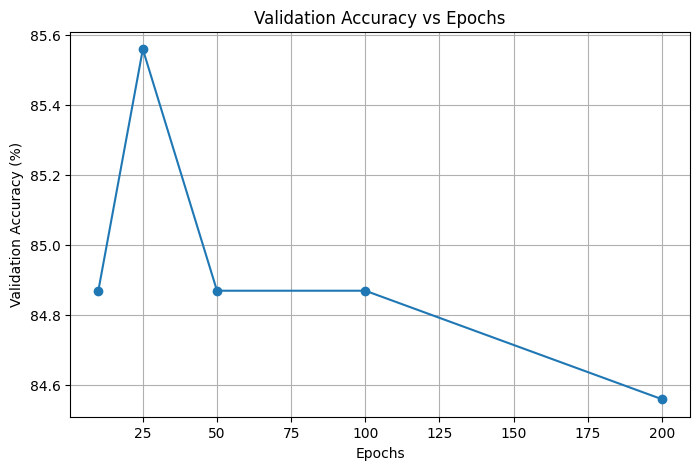

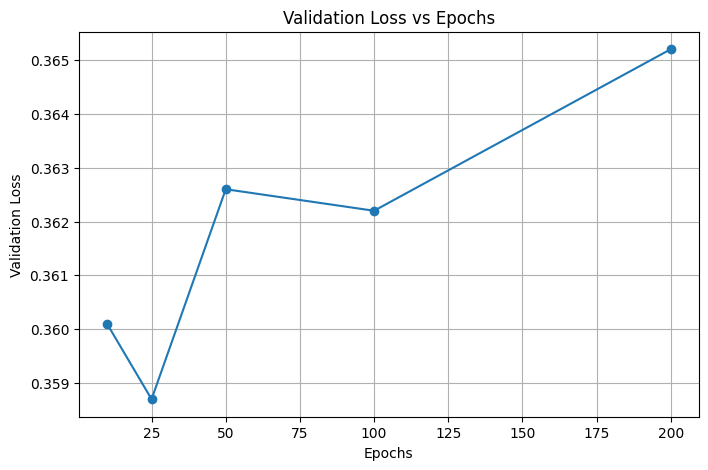

,Epochs,Validation Accuracy (%),Validation Loss,Training Time (sec)
0,10,84.87,0.3601,19.91
1,25,85.56,0.3587,5.30
2,50,84.87,0.3626,4.14
3,100,84.87,0.3622,4.15
4,200,84.56,0.3652,5.46


In [222]:
epoch_values = [10, 25, 50, 100, 200]

results = []

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for ep in epoch_values:

    print(f"\nTraining with {ep} epochs...")

    model = Sequential()

    model.add(Dense(32, activation='relu', input_dim=12))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=ep,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    end = time.time()

    results.append({
        "Epochs": ep,
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1] * 100, 2),
        "Validation Loss": round(history.history['val_loss'][-1], 4),
        "Training Time (sec)": round(end - start, 2)
    })

comparison_df = pd.DataFrame(results)

print("\nComparison Table")
print(comparison_df)

# Accuracy vs Epoch
plt.figure(figsize=(8,5))
plt.plot(comparison_df["Epochs"],
         comparison_df["Validation Accuracy (%)"],
         marker='o')
plt.title("Validation Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy (%)")
plt.grid(True)
plt.show()

# Loss vs Epoch
plt.figure(figsize=(8,5))
plt.plot(comparison_df["Epochs"],
         comparison_df["Validation Loss"],
         marker='o')
plt.title("Validation Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.show()

comparison_df

**Which number of epochs gave the best performance and why?**

Answer:

The model trained for 25 epochs gave the best overall performance. It achieved the highest validation accuracy (85.56%) and the lowest validation loss (0.3587). Increasing the number of epochs beyond 25 did not improve performance; instead, the validation accuracy remained the same or decreased slightly while the validation loss increased. Therefore, 25 epochs provide the best balance between learning and generalization for this dataset.

**Task 8**


Training with Batch Size = 8


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with Batch Size = 16

Training with Batch Size = 32

Training with Batch Size = 64

Training with Batch Size = 128

Batch Size Comparison
   Batch Size  Validation Accuracy (%)  Validation Loss  Training Time (sec)
0           8                    85.87           0.3745                59.77
1          16                    85.00           0.3593                14.71
2          32                    85.87           0.3547                 5.25
3          64                    85.75           0.3634                 5.50
4         128                    81.88           0.4130                 2.73


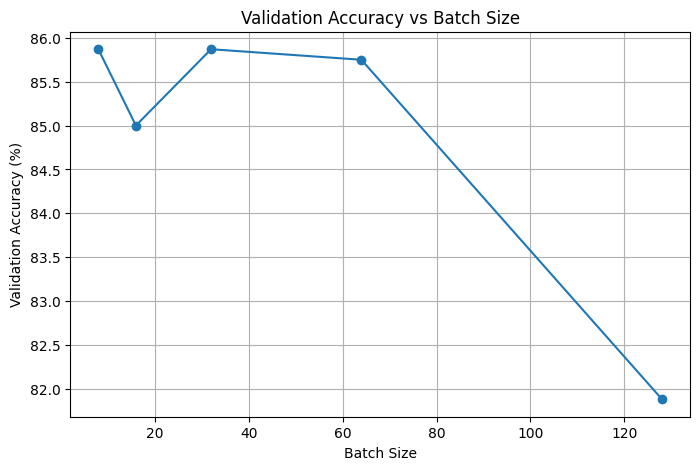

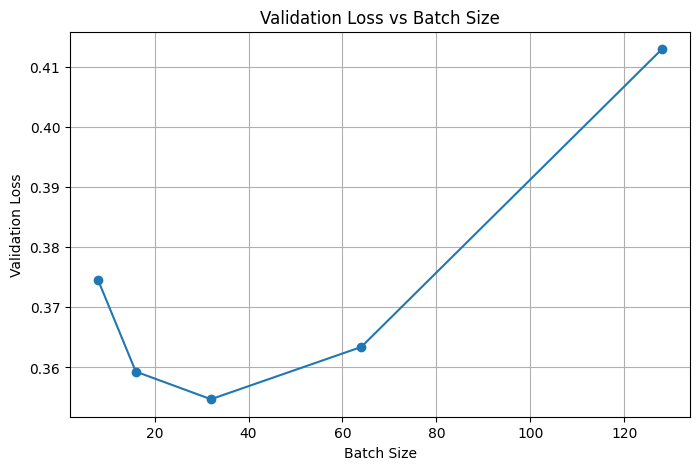

,Batch Size,Validation Accuracy (%),Validation Loss,Training Time (sec)
0,8,85.87,0.3745,59.77
1,16,85.00,0.3593,14.71
2,32,85.87,0.3547,5.25
3,64,85.75,0.3634,5.50
4,128,81.88,0.4130,2.73


In [223]:
import time
import pandas as pd
import matplotlib.pyplot as plt

from keras.models import Sequential
from keras.layers import Dense
from keras.callbacks import EarlyStopping


batch_sizes = [8, 16, 32, 64, 128]

results = []


early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

for batch in batch_sizes:

    print(f"\nTraining with Batch Size = {batch}")


    model = Sequential()

    model.add(Dense(32, activation='relu', input_dim=12))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))


    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    start = time.time()

    # Train model
    history = model.fit(
        X_train,
        y_train,
        validation_split=0.2,
        epochs=100,
        batch_size=batch,
        callbacks=[early_stop],
        verbose=0
    )

    end = time.time()


    results.append({
        "Batch Size": batch,
        "Validation Accuracy (%)": round(history.history['val_accuracy'][-1] * 100, 2),
        "Validation Loss": round(history.history['val_loss'][-1], 4),
        "Training Time (sec)": round(end - start, 2)
    })

comparison_df = pd.DataFrame(results)

print("\nBatch Size Comparison")
print(comparison_df)
plt.figure(figsize=(8,5))
plt.plot(
    comparison_df["Batch Size"],
    comparison_df["Validation Accuracy (%)"],
    marker='o'
)
plt.title("Validation Accuracy vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Validation Accuracy (%)")
plt.grid(True)
plt.show()


plt.figure(figsize=(8,5))
plt.plot(
    comparison_df["Batch Size"],
    comparison_df["Validation Loss"],
    marker='o'
)
plt.title("Validation Loss vs Batch Size")
plt.xlabel("Batch Size")
plt.ylabel("Validation Loss")
plt.grid(True)
plt.show()

comparison_df

**Which batch size performed the best and why?**

Answer:

The batch size of 32 performed the best overall. Although batch sizes 8 and 32 achieved the same highest validation accuracy (85.87%), the batch size of 32 produced the lowest validation loss (0.3547) and required much less training time (5.25 seconds compared to 59.77 seconds for batch size 8). Therefore, batch size 32 provides the best balance between prediction accuracy, model generalization, and computational efficiency.

**Task 9**

In [224]:
model = Sequential()

# Hidden Layer
model.add(Dense(
    units=32,
    activation='relu',
    kernel_initializer='random_normal',
    input_dim=12
))

# Dropout Layer
model.add(Dropout(0.2))

# Output Layer
model.add(Dense(
    units=1,
    activation='sigmoid'
))

# Compile Model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

start = time.time()

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=25,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

end = time.time()

# Evaluate Model
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("\nImproved ANN Results")
print("----------------------------")
print(f"Test Accuracy : {accuracy*100:.2f}%")
print(f"Test Loss     : {loss:.4f}")
print(f"Training Time : {end-start:.2f} sec")

Epoch 1/25


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.7780 - loss: 0.5246 - val_accuracy: 0.8106 - val_loss: 0.4385
Epoch 2/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.8167 - loss: 0.4278 - val_accuracy: 0.8200 - val_loss: 0.4180
Epoch 3/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8247 - loss: 0.4083 - val_accuracy: 0.8250 - val_loss: 0.4014
Epoch 4/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8419 - loss: 0.3892 - val_accuracy: 0.8381 - val_loss: 0.3862
Epoch 5/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8489 - loss: 0.3761 - val_accuracy: 0.8462 - val_loss: 0.3749
Epoch 6/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8462 - loss: 0.3671 - val_accuracy: 0.8469 - val_loss: 0.3685
Epoch 7/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8505 - loss: 0.3651 - val_accuracy: 0.8481 - val_loss: 0.3639
Epoch 8/25
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.8528 - loss: 0.3594 - val_accuracy: 0.8500 - va

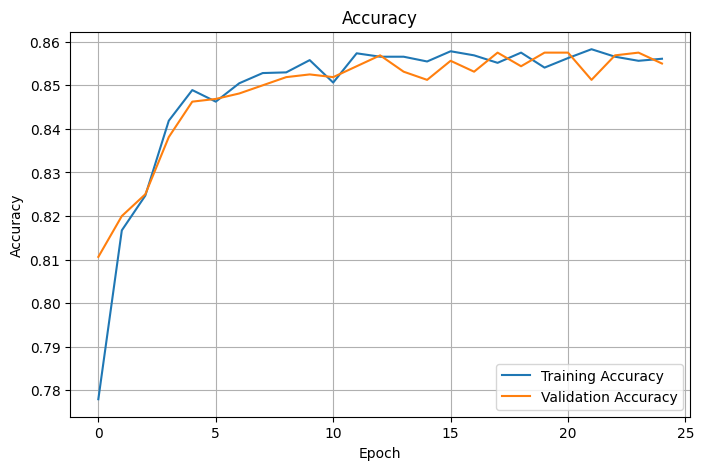

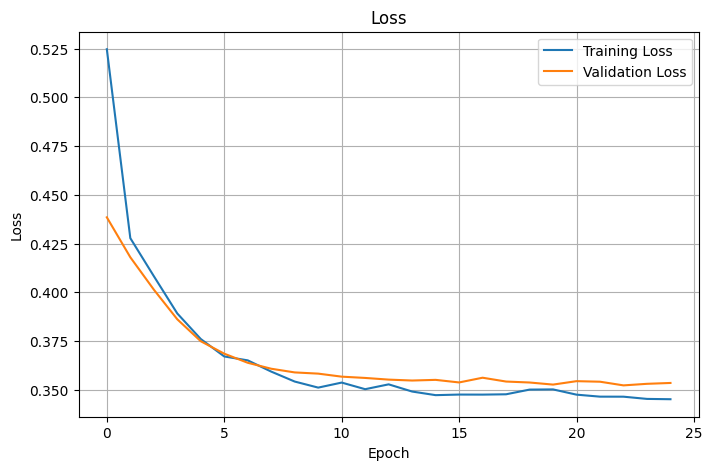

In [225]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

# Loss Plot
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Task 10**

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
========== ANN Evaluation ==========
Accuracy : 86.25%
Precision: 0.7519
Recall   : 0.4790
F1-Score : 0.5852

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.96      0.92      1595
           1       0.75      0.48      0.59       405

    accuracy                           0.86      2000
   macro avg       0.82      0.72      0.75      2000
weighted avg       0.85      0.86      0.85      2000



<Figure size 600x600 with 0 Axes>

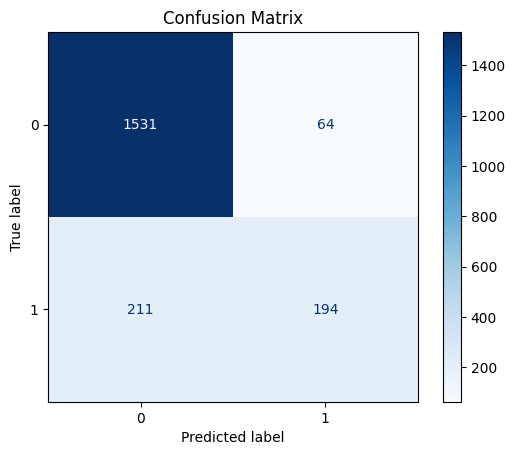

In [226]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Predict on test data
y_pred_prob = model.predict(X_test)

# Convert probabilities to binary labels
y_pred = (y_pred_prob > 0.5).astype(int)

# Evaluation Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("========== ANN Evaluation ==========")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

# Classification Report
print("\nClassification Report")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

In [ ]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred_proba = classifier.predict(X_test)

# Calculate ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# Calculate AUC
roc_auc = auc(fpr, tpr)

print(f"AUC: {roc_auc:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
AUC: 0.8701


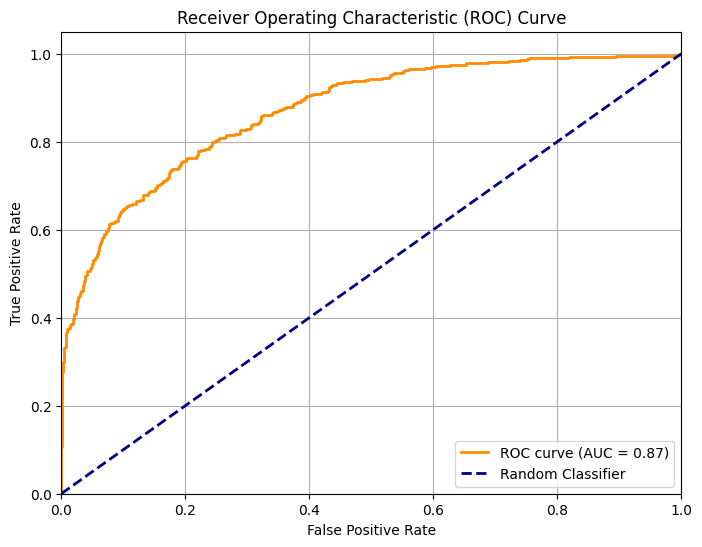

In [ ]:
# Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

In [ ]:
from keras.models import load_model

loaded_model = load_model(model_save_path)

print("Loaded model summary:")
loaded_model.summary()

Loaded model summary:


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_43 (Dense)                │ (None, 4)              │            52 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 8)              │            40 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_47 (Dense)                │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_48 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,873 (34.66 KB)

 Trainable params: 2,957 (11.55 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,916 (23.11 KB)

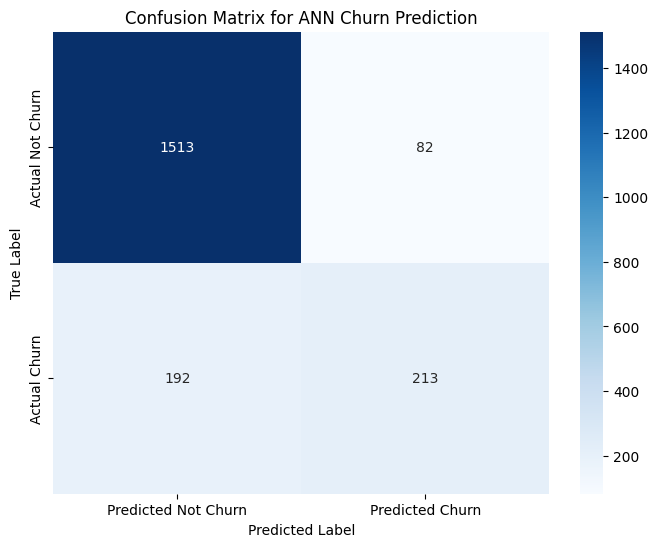

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(8, 6))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Not Churn', 'Predicted Churn'],
            yticklabels=['Actual Not Churn', 'Actual Churn'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for ANN Churn Prediction')
plt.show()

In [227]:
model.summary()

Model: "sequential_46"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_216 (Dense)               │ (None, 32)             │           416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_217 (Dense)               │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,349 (5.27 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 900 (3.52 KB)